/var/folders/bx/kch8q2y16gn99b5qlh8lj3br0000gn/T/ipykernel_8058/3499308977.py:35: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


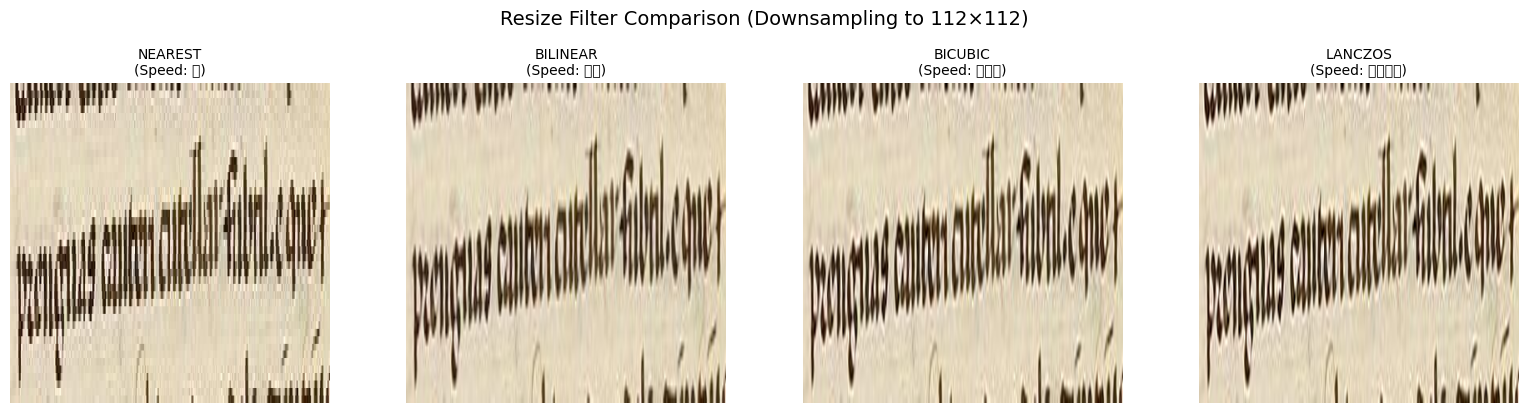

📊 Filter Characteristics:
------------------------------------------------------------
NEAREST  : Fastest, just picks closest pixel → blocky artifacts
BILINEAR : 2×2 neighborhood average → smooth but slightly blurry
BICUBIC  : 4×4 neighborhood → smoother edges, good for photos
LANCZOS  : 8×8 neighborhood → sharpest text, best for documents
------------------------------------------------------------
✅ For manuscripts: LANCZOS preserves text edges best!


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from dotenv import load_dotenv
load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
# Load your image
input_path = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines", "extraction_20260430_190006","37_f_032v_033", "37_f_032v_033_line_166.png")
img = Image.open(input_path).convert('RGB')

# Resize to a small size to exaggerate differences
target_size = 384  # Half of 224

filters = {
    'NEAREST': Image.Resampling.NEAREST,      # Fastest, blocky/pixelated
    'BILINEAR': Image.Resampling.BILINEAR,     # Good balance
    'BICUBIC': Image.Resampling.BICUBIC,       # Smoother than bilinear
    'LANCZOS': Image.Resampling.LANCZOS,       # Highest quality, sharpest
}

plt.figure(figsize=(16, 4))

for i, (name, filter_method) in enumerate(filters.items(), 1):
    img_resized = img.resize((target_size, target_size), filter_method)
    
    plt.subplot(1, 4, i)
    plt.imshow(img_resized)
    plt.title(f"{name}\n(Speed: {'⭐' if name=='NEAREST' else '⭐⭐' if name=='BILINEAR' else '⭐⭐⭐' if name=='BICUBIC' else '⭐⭐⭐⭐'})", 
              fontsize=10)
    plt.axis('off')

plt.suptitle("Resize Filter Comparison (Downsampling to 112×112)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print technical details
print("📊 Filter Characteristics:")
print("-" * 60)
print("NEAREST  : Fastest, just picks closest pixel → blocky artifacts")
print("BILINEAR : 2×2 neighborhood average → smooth but slightly blurry")
print("BICUBIC  : 4×4 neighborhood → smoother edges, good for photos")
print("LANCZOS  : 8×8 neighborhood → sharpest text, best for documents")
print("-" * 60)
print("✅ For manuscripts: LANCZOS preserves text edges best!")

📐 Dimension Check:
Original: (399, 43)
After resize+pad: (224, 224)
✅ Success: True


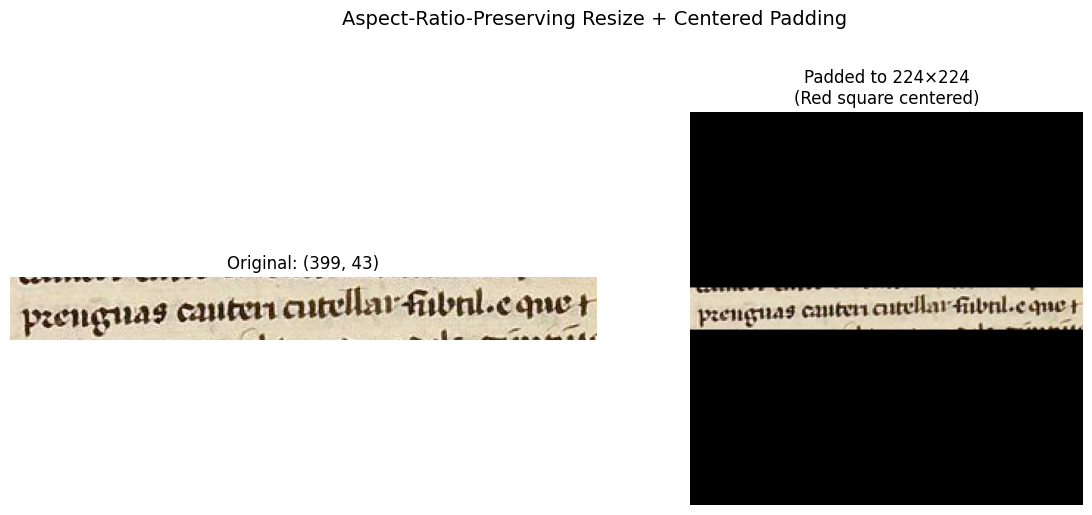

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torchvision.transforms as T

def pad_centered_correct(img, target_size=224, fill_color=0):
    """Correct centered padding that always produces target_size × target_size"""
    w, h = img.size
    
    # Resize longest side to target_size, keep aspect ratio
    if w > h:
        new_w = target_size
        new_h = int(round(h * (target_size / w)))  # round to avoid float issues
    else:
        new_h = target_size
        new_w = int(round(w * (target_size / h)))
    
    img_resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    
    # Calculate padding needed
    pad_w = target_size - new_w
    pad_h = target_size - new_h
    
    # ✅ Correct centered padding: handles odd values properly
    # Format: (left, top, right, bottom)
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w//2, pad_h - pad_h//2)
    
    return T.functional.pad(img_resized, padding, fill=fill_color)

# Create a test image with asymmetric dimensions to trigger odd padding
#test_img = Image.new('RGB', (300, 200), color='lightblue')

input_path = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines", "extraction_20260430_190006","37_f_032v_033", "37_f_032v_033_line_166.png")
test_img = Image.open(input_path).convert('RGB')

#draw = ImageDraw.Draw(test_img)

# Apply correct padding
img_padded = pad_centered_correct(test_img, target_size=224, fill_color=0)

print("📐 Dimension Check:")
print(f"Original: {test_img.size}")
print(f"After resize+pad: {img_padded.size}")  # Should be exactly (224, 224)
print(f"✅ Success: {img_padded.size == (224, 224)}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_img)
plt.title(f"Original: {test_img.size}", fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_padded)
plt.title(f"Padded to 224×224\n(Red square centered)", fontsize=12)
plt.axis('off')

plt.suptitle("Aspect-Ratio-Preserving Resize + Centered Padding", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


📐 Dimension Check:
Original: (419, 121)
After resize+pad: (224, 224)
✅ Success: True


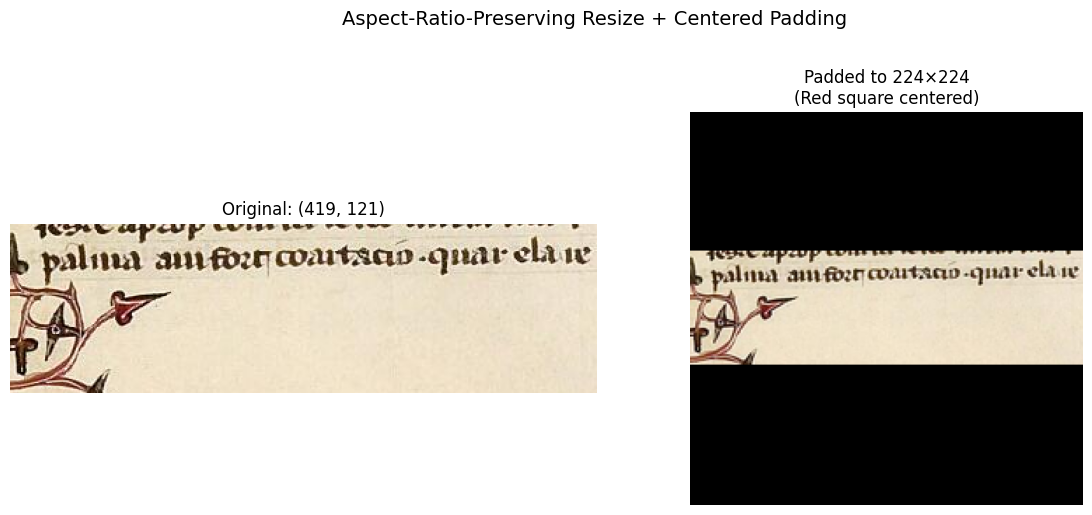

In [11]:
input_path = os.path.join(PROJECT_ROOT, "data", "processed", "extracted_lines", "extraction_20260430_190006","71_f_066v_067", "71_f_066v_067_line_152.png")
test_img = Image.open(input_path).convert('RGB')

#draw = ImageDraw.Draw(test_img)

# Apply correct padding
img_padded = pad_centered_correct(test_img, target_size=224, fill_color=0)

print("📐 Dimension Check:")
print(f"Original: {test_img.size}")
print(f"After resize+pad: {img_padded.size}")  # Should be exactly (224, 224)
print(f"✅ Success: {img_padded.size == (224, 224)}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(test_img)
plt.title(f"Original: {test_img.size}", fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_padded)
plt.title(f"Padded to 224×224\n(Red square centered)", fontsize=12)
plt.axis('off')

plt.suptitle("Aspect-Ratio-Preserving Resize + Centered Padding", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()